In [1]:
import pandas as pd
import numpy as np
import math
import random
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

MODELS_CACHE = {}

def main(year, sim_count):
    
    data = pd.read_csv("../../data/data_official.csv")
    
    if year not in MODELS_CACHE:
        try:
            with open(f'../RFmodels/rf_model_{year}.pkl', 'rb') as f:
                MODELS_CACHE[year] = pickle.load(f)
        except FileNotFoundError:
            raise ValueError(f"Model for year {year} not found. Please train it first.")
            
    model = MODELS_CACHE[year]
    
    data['Sim_Wins'] = [-1 for _ in range(len(data))]
    data['R68_win%'] = [1.0 for _ in range(len(data))]
    data['R64_win%'] = [0.0 for _ in range(len(data))]
    data['R32_win%'] = [0.0 for _ in range(len(data))]
    data['S16_win%'] = [0.0 for _ in range(len(data))]
    data['E8_win%'] = [0.0 for _ in range(len(data))]
    data['F4_win%'] = [0.0 for _ in range(len(data))]
    data['CG_win%'] = [0.0 for _ in range(len(data))]
    data['R68_opp'] = ["N/A" for _ in range(len(data))]
    data['R64_opp'] = ["N/A" for _ in range(len(data))]
    data['R32_opp'] = ["N/A" for _ in range(len(data))]
    data['S16_opp'] = ["N/A" for _ in range(len(data))]
    data['E8_opp'] = ["N/A" for _ in range(len(data))]
    data['F4_opp'] = ["N/A" for _ in range(len(data))]
    data['CG_opp'] = ["N/A" for _ in range(len(data))]
    
    i = 0
    
    sims = []
    scores = []
        
    while i < sim_count:
        
        sim_df = simulation(year, i, data, model)
        
        score = 0

        score = score + (10 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 0) & (sim_df["Sim_Wins"] > 0)])))
        score = score + (20 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 1) & (sim_df["Sim_Wins"] > 1)])))
        score = score + (40 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 2) & (sim_df["Sim_Wins"] > 2)])))
        score = score + (80 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 3) & (sim_df["Sim_Wins"] > 3)])))
        score = score + (160 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 4) & (sim_df["Sim_Wins"] > 4)])))
        score = score + (320 * (len(sim_df[(sim_df["YEAR"] == year) & (sim_df["Wins"] > 5) & (sim_df["Sim_Wins"] > 5)])))
        
        sims.append(sim_df)
        scores.append(score)
        i = i+1
                
    full_df = pd.concat(sims, axis=0).reset_index(drop=True)
    
    final_df = calc_outcome(full_df)
    
    final_df1 = final_df[['sim_num', 'QUAD ID', 'TEAM', 'SEED', 'Wins', 'Sim_Wins', 'R68_win%', 'R68_opp', 'R64_win%', 'R64_opp', 'R32_win%', 'R32_opp', 'S16_win%', 'S16_opp', 'E8_win%', 'E8_opp', 'F4_win%', 'F4_opp', 'CG_win%', 'CG_opp', 'Outcome_%']]
        
    return final_df1, scores

def simulation(year, sim_num, data, model):
    
    data = data.copy()
    
    data['sim_num'] = sim_num + 1
    
    df1 = region_simulation(data, year, 1, model)
    df1n = df1[df1["QUAD ID"] == 1]
    df2 = region_simulation(data, year, 2, model)
    df2n = df2[df2["QUAD ID"] == 2]
    df3 = region_simulation(data, year, 3, model)
    df3n = df3[df3["QUAD ID"] == 3]
    df4 = region_simulation(data, year, 4, model)
    df4n = df4[df4["QUAD ID"] == 4]
    
    df = pd.concat([df1n, df2n, df3n, df4n])
        
    df = final4(df, year, model)
    
    df = championship(df, year, model)
    
    df_year = df[df["YEAR"] == year]
    dfn = df_year[['sim_num', 'YEAR', 'QUAD ID', 'TEAM', 'SEED', 'Wins', 'Sim_Wins', 'R68_win%', 'R68_opp', 'R64_win%', 'R64_opp', 'R32_win%', 'R32_opp', 'S16_win%', 'S16_opp', 'E8_win%', 'E8_opp', 'F4_win%', 'F4_opp', 'CG_win%', 'CG_opp']]
                            
    return dfn

def region_simulation(data, year, quad, model):
    
    seeds = list(range(1,17))

    ###########################################################################
    # FIRST FOUR
    
    for seed in seeds:
    
        if data[(data["SEED"] == seed) & (data["YEAR"] == year) & (data["QUAD ID"] == quad)].shape[0] > 1:
            
            data = same_seed(data, year, quad, seed, model)
    ##########################################################################
    ##########################################################################
    # FIRST ROUND (R64)
        
    data = round64(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # SECOND ROUND (R32)
    
    data = round32(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # SWEET 16
    
    data = sweet16(data, year, quad, model)
    
    ##########################################################################
    ##########################################################################
    # ELITE 8
    
    data = elite8(data, year, quad, model)
    
    return data

def same_seed(data, year, quad, seed, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["SEED"] == seed)].copy()
    team0 = subdf.head(1)
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf.tail(1)
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    
    data.loc[team0index, "R68_win%"] = perc
    data.loc[team1index, "R68_win%"] = 1-perc
    data.loc[team0index, "R68_opp"] = team1name
    data.loc[team1index, "R68_opp"] = team0name
    
    winner = weighted_coin_flip(perc)

    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 0

    else:
        data.loc[team0index, "Sim_Wins"] = 0
        
    return data

def round64(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    seeds1 = [1,2,3,4,5,6,7,8]
    seeds2 = [16,15,14,13,12,11,10,9]
    
    for i in range(0,8):
        
        rdf = subdf[(subdf["SEED"] == seeds1[i]) | (subdf["SEED"] == seeds2[i])]
        team0 = rdf.head(1)
        team0name = str(team0["TEAM"].iloc[0])
        team0index = team0["TEAM"].index
        team1 = rdf.tail(1)
        team1name = str(team1["TEAM"].iloc[0])
        team1index = team1["TEAM"].index
                
        perc = find_percentages(data, team0name, team1name, year, model)
        
        data.loc[team0index, "R64_win%"] = perc
        data.loc[team1index, "R64_win%"] = 1-perc
        data.loc[team0index, "R64_opp"] = team1name
        data.loc[team1index, "R64_opp"] = team0name

        winner = weighted_coin_flip(perc)
        
        if winner == 1:
            data.loc[team1index, "Sim_Wins"] = 0

        else:
            data.loc[team0index, "Sim_Wins"] = 0

    return data

def round32(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf[(subdf["SEED"] == 1) | (subdf["SEED"] == 16)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 8) | (subdf["SEED"] == 9)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 5) | (subdf["SEED"] == 12)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 4) | (subdf["SEED"] == 13)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 6) | (subdf["SEED"] == 11)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 3) | (subdf["SEED"] == 14)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
    
    team0 = subdf[(subdf["SEED"] == 7) | (subdf["SEED"] == 10)]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf[(subdf["SEED"] == 2) | (subdf["SEED"] == 15)]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "R32_win%"] = perc
    data.loc[team1index, "R32_win%"] = 1-perc
    data.loc[team0index, "R32_opp"] = team1name
    data.loc[team1index, "R32_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 1
    else:
        data.loc[team0index, "Sim_Wins"] = 1
        
    return data

def sweet16(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    options1 = [1,8,9,16]
    for i in options1:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    options2 = [4,5,12,13]
    for i in options2:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "S16_win%"] = perc
    data.loc[team1index, "S16_win%"] = 1-perc
    data.loc[team0index, "S16_opp"] = team1name
    data.loc[team1index, "S16_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 2
    else:
        data.loc[team0index, "Sim_Wins"] = 2

    options3 = [3,6,11,14]
    for i in options3:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    options4 = [2,7,10,15]
    for i in options4:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "S16_win%"] = perc
    data.loc[team1index, "S16_win%"] = 1-perc
    data.loc[team0index, "S16_opp"] = team1name
    data.loc[team1index, "S16_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 2
    else:
        data.loc[team0index, "Sim_Wins"] = 2  
    
    return data

def elite8(data, year, quad, model):
    
    subdf = data[(data["YEAR"] == year) & (data["QUAD ID"] == quad) & (data["Sim_Wins"] == -1)]
    
    options1 = [1,4,5,8,9,12,13,16]
    for i in options1:
        if not subdf[subdf["SEED"] == i].empty:
            team0 = subdf[subdf["SEED"] == i]
            break
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    
    options2 = [2,3,6,7,10,11,14,15]
    for i in options2:
        if not subdf[subdf["SEED"] == i].empty:
            team1 = subdf[subdf["SEED"] == i]
            break
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "E8_win%"] = perc
    data.loc[team1index, "E8_win%"] = 1-perc
    data.loc[team0index, "E8_opp"] = team1name
    data.loc[team1index, "E8_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 3
    else:
        data.loc[team0index, "Sim_Wins"] = 3
        
    return data

def final4(data, year, model):
    
    subdf = data[(data["YEAR"] == year) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf[subdf["QUAD ID"] == 1]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
        
    team1 = subdf[subdf["QUAD ID"] == 2]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "F4_win%"] = perc
    data.loc[team1index, "F4_win%"] = 1-perc
    data.loc[team0index, "F4_opp"] = team1name
    data.loc[team1index, "F4_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 4
    else:
        data.loc[team0index, "Sim_Wins"] = 4
        
    team0 = subdf[subdf["QUAD ID"] == 3]
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
        
    team1 = subdf[subdf["QUAD ID"] == 4]
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
        
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "F4_win%"] = perc
    data.loc[team1index, "F4_win%"] = 1-perc
    data.loc[team0index, "F4_opp"] = team1name
    data.loc[team1index, "F4_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 4
    else:
        data.loc[team0index, "Sim_Wins"] = 4    
    
    return data

def championship(data, year, model):
    
    subdf = data[(data["YEAR"] == year) & (data["Sim_Wins"] == -1)]
    
    team0 = subdf.head(1)
    team0name = str(team0["TEAM"].iloc[0])
    team0index = team0["TEAM"].index
    team1 = subdf.tail(1)
    team1name = str(team1["TEAM"].iloc[0])
    team1index = team1["TEAM"].index
    
    perc = find_percentages(data, team0name, team1name, year, model)
    data.loc[team0index, "CG_win%"] = perc
    data.loc[team1index, "CG_win%"] = 1-perc
    data.loc[team0index, "CG_opp"] = team1name
    data.loc[team1index, "CG_opp"] = team0name
    winner = weighted_coin_flip(perc)
    if winner == 1:
        data.loc[team1index, "Sim_Wins"] = 5
        data.loc[team0index, "Sim_Wins"] = 6
    else:
        data.loc[team0index, "Sim_Wins"] = 5
        data.loc[team1index, "Sim_Wins"] = 6    
    
    return data

def game_style(df, team0, team1, year):
    
    cols = ['KADJ T',
       'KADJ O', 'KADJ D', 'EFG%', 'EFG%D', 'FTR', 'FTRD', 'TOV%',
       'TOV%D', 'OREB%', 'DREB%', '2PT%', '2PT%D', '3PT%', '3PT%D', 'AST%',
       '2PTR', '3PTR', '2PTRD', '3PTRD', 'EFF HGT', 'EXP', 'FT%',
       'ELITE SOS']
    
    t0 = df[(df["TEAM"] == team0) & (df["YEAR"] == year)].reset_index(drop=True)
    t1 = df[(df["TEAM"] == team1) & (df["YEAR"] == year)].reset_index(drop=True)
    
    game = pd.DataFrame()
    
    for col in cols:
        game[col] = t0[col] - t1[col]
    game.insert(0, "YEAR", year)
    game.insert(1, "Team0", t0["TEAM"])
    game.insert(2, "Team1", t1["TEAM"])
    
    return game

def find_percentages(df, team0, team1, year, model):
    
    features = ['KADJ T', 'KADJ O', 'KADJ D', 'EFG%', 'EFG%D', 'FTR', 'FTRD', 
                'TOV%', 'TOV%D', 'OREB%', 'DREB%', '2PT%', '2PT%D', '3PT%', 
                '3PT%D', 'AST%', '2PTR', '3PTR', '2PTRD', '3PTRD', 'EFF HGT', 
                'EXP', 'FT%', 'ELITE SOS']
    
    game_01 = game_style(df, team0, team1, year)
    game_10 = game_style(df, team1, team0, year)
    
    X_test_01 = game_01[features].values
    X_test_10 = game_10[features].values
    
    probs_01 = model.predict_proba(X_test_01)[0]
    probs_10 = model.predict_proba(X_test_10)[0]
    
    team0_win_prob = (probs_01[0] + probs_10[1]) / 2
    team1_win_prob = (probs_01[1] + probs_10[0]) / 2
    
    return team0_win_prob

def weighted_coin_flip(perc1):
    
    num = random.random()
    
    if num < perc1:
        return 1
    
    else:
        return 2
    
def calc_outcome(df):
    
    df['Outcome_%'] = [0 for _ in range(len(df))]
    
    df.loc[df['Sim_Wins'] == 6, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * df['F4_win%'] * df['CG_win%']
    df.loc[df['Sim_Wins'] == 5, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * df['F4_win%'] * (1-df['CG_win%'])
    df.loc[df['Sim_Wins'] == 4, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * df['E8_win%'] * (1-df['F4_win%'])
    df.loc[df['Sim_Wins'] == 3, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * df['S16_win%'] * (1-df['E8_win%'])
    df.loc[df['Sim_Wins'] == 2, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * df['R32_win%'] * (1-df['S16_win%'])
    df.loc[df['Sim_Wins'] == 1, 'Outcome_%'] = df['R68_win%'] * df['R64_win%'] * (1-df['R32_win%'])
    df.loc[(df['Sim_Wins'] == 0) & (df['R64_win%'] != 0), 'Outcome_%'] = df['R68_win%'] * (1-df['R64_win%'])
    df.loc[(df['Sim_Wins'] == 0) & (df['R64_win%'] == 0), 'Outcome_%'] = (1-df['R68_win%'])
    
    df['R68_win%'] = df['R68_win%'].mul(100).round(3)
    df['R64_win%'] = df['R64_win%'].mul(100).round(3)
    df['R32_win%'] = df['R32_win%'].mul(100).round(3)
    df['S16_win%'] = df['S16_win%'].mul(100).round(3)
    df['E8_win%'] = df['E8_win%'].mul(100).round(3)
    df['F4_win%'] = df['F4_win%'].mul(100).round(3)
    df['CG_win%'] = df['CG_win%'].mul(100).round(3)
    df['Outcome_%'] = df['Outcome_%'].mul(100).round(3)
        
    return df

In [2]:
df, scores = main(2024, 10000)

In [3]:
import numpy as np

top_5_indices = np.argsort(scores)[-5:][::-1]  
top_5 = [(i+1, scores[i]) for i in top_5_indices] 

bottom_5_indices = np.argsort(scores)[:5]  
bottom_5 = [(i+1, scores[i]) for i in bottom_5_indices]

avg_score = np.mean(scores)

print("=" * 40)
print("TOP 5 SCORES")
print("=" * 40)
for sim_num, score in top_5:
    print(f"Sim #{sim_num}: {score}")

print("\n" + "=" * 40)
print("BOTTOM 5 SCORES")
print("=" * 40)
for sim_num, score in bottom_5:
    print(f"Sim #{sim_num}: {score}")

print("\n" + "=" * 40)
print(f"AVERAGE SCORE: {avg_score:.2f}")
print("=" * 40)

TOP 5 SCORES
Sim #9465: 1630
Sim #5568: 1630
Sim #9339: 1590
Sim #3106: 1560
Sim #3753: 1540

BOTTOM 5 SCORES
Sim #9219: 200
Sim #3156: 220
Sim #1307: 220
Sim #5019: 220
Sim #6193: 230

AVERAGE SCORE: 722.40


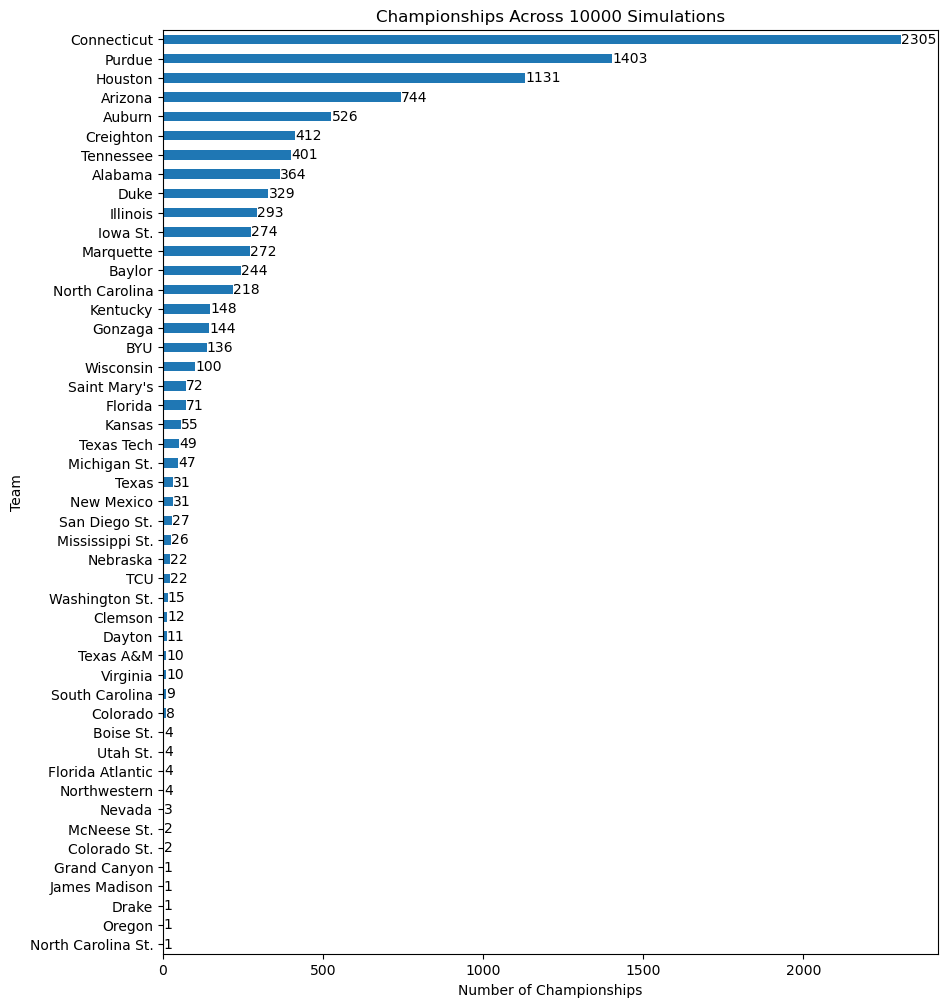

In [4]:
import matplotlib.pyplot as plt

champ_counts = df.loc[df['Sim_Wins'] == 6, 'TEAM'].value_counts()

ax = champ_counts[::-1].plot(kind='barh', figsize=(10,12))

plt.title("Championships Across 10000 Simulations")
plt.ylabel("Team")
plt.xlabel("Number of Championships")
plt.yticks(rotation=0)

for i, v in enumerate(champ_counts[::-1]):
    ax.text(v + 0.3, i, str(v), va='center')

plt.show()

In [5]:
from itertools import zip_longest
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] == 6)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Championships by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Championships by Team for 10000 Simulations

Connecticut       2305 --> 23.05%          Texas              31 --> 0.31%            James Madison       1 --> 0.01%         
Purdue            1403 --> 14.03%          New Mexico         31 --> 0.31%            Grand Canyon        1 --> 0.01%         
Houston           1131 --> 11.31%          San Diego St.      27 --> 0.27%            Duquesne            0 --> 0.0%          
Arizona           744 --> 7.44%            Mississippi St.    26 --> 0.26%            UAB                 0 --> 0.0%          
Auburn            526 --> 5.26%            Nebraska           22 --> 0.22%            Samford             0 --> 0.0%          
Creighton         412 --> 4.12%            TCU                22 --> 0.22%            Vermont             0 --> 0.0%          
Tennessee         401 --> 4.01%            Washington St.     15 --> 0.15%            College of Charleston   0 --> 0.0%      
Alabama           364 --> 3.64%            Clemson            12 -

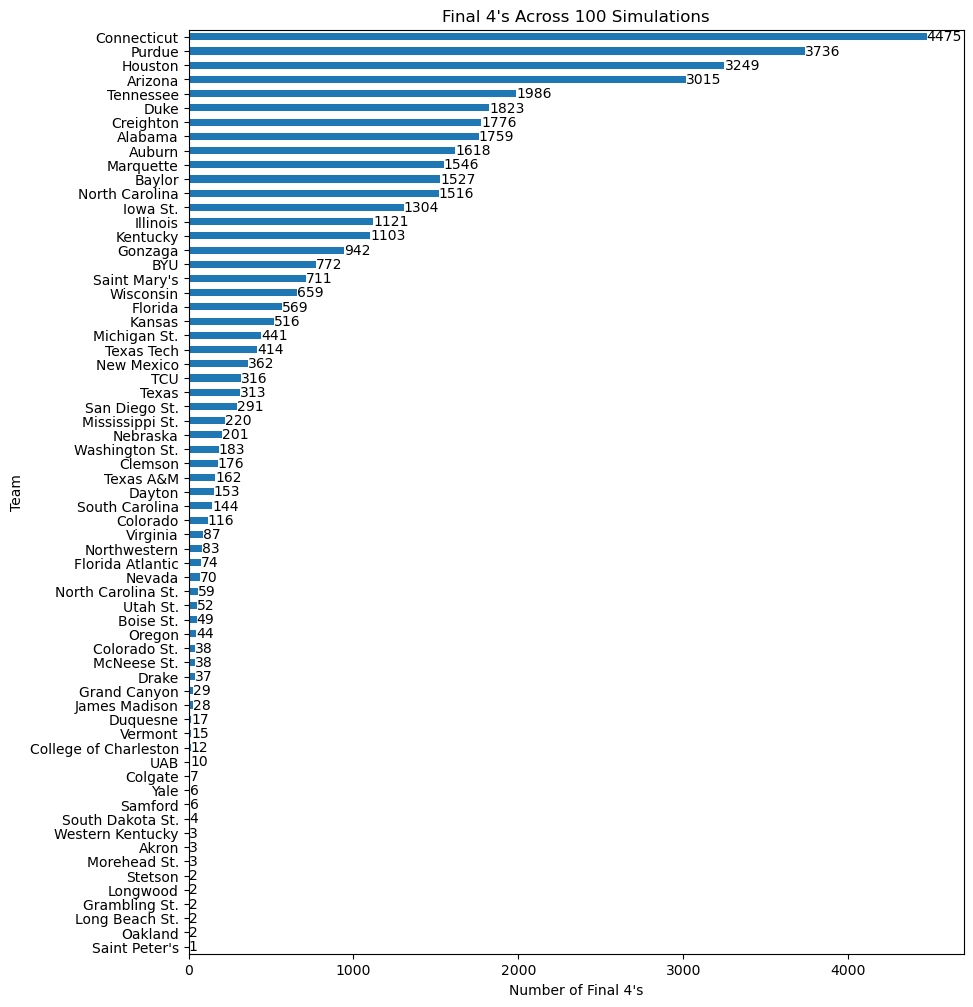

In [6]:
import matplotlib.pyplot as plt

champ_counts = df.loc[df['Sim_Wins'] >= 4, 'TEAM'].value_counts()

ax = champ_counts[::-1].plot(kind='barh', figsize=(10,12))

plt.title("Final 4's Across 100 Simulations")
plt.ylabel("Team")
plt.xlabel("Number of Final 4's")
plt.yticks(rotation=0)

for i, v in enumerate(champ_counts[::-1]):
    ax.text(v + 0.3, i, str(v), va='center')

plt.show()

In [7]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 4)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Final 4's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Final 4's by Team for 10000 Simulations

Connecticut       4475 --> 44.75%          New Mexico        362 --> 3.62%            Grand Canyon       29 --> 0.29%         
Purdue            3736 --> 37.36%          TCU               316 --> 3.16%            James Madison      28 --> 0.28%         
Houston           3249 --> 32.49%          Texas             313 --> 3.13%            Duquesne           17 --> 0.17%         
Arizona           3015 --> 30.15%          San Diego St.     291 --> 2.91%            Vermont            15 --> 0.15%         
Tennessee         1986 --> 19.86%          Mississippi St.   220 --> 2.2%             College of Charleston  12 --> 0.12%     
Duke              1823 --> 18.23%          Nebraska          201 --> 2.01%            UAB                10 --> 0.1%          
Creighton         1776 --> 17.76%          Washington St.    183 --> 1.83%            Colgate             7 --> 0.07%         
Alabama           1759 --> 17.59%          Clemson           176 --> 1

In [8]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 3)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Elite 8's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Elite 8's by Team for 10000 Simulations

Connecticut       5896 --> 58.96%          Michigan St.      1084 --> 10.84%          Duquesne          134 --> 1.34%         
Purdue            5535 --> 55.35%          New Mexico        931 --> 9.31%            Colorado St.      125 --> 1.25%         
Arizona           4896 --> 48.96%          TCU               871 --> 8.71%            James Madison     109 --> 1.09%         
Houston           4570 --> 45.7%           Washington St.    869 --> 8.69%            College of Charleston  74 --> 0.74%     
Tennessee         3971 --> 39.71%          San Diego St.     685 --> 6.85%            UAB                61 --> 0.61%         
Marquette         3631 --> 36.31%          Mississippi St.   647 --> 6.47%            Colgate            54 --> 0.54%         
Creighton         3624 --> 36.24%          South Carolina    632 --> 6.32%            Morehead St.       52 --> 0.52%         
Alabama           3301 --> 33.01%          Nebraska          562 --> 5

In [9]:
teams = list(df["TEAM"].unique())
cc = []
for team in teams:
    x = df[(df["TEAM"] == team) & (df["Sim_Wins"] >= 2)]
    dfx = {}
    dfx["TEAM"] = team
    dfx["Seed"] = np.mean(x["SEED"])
    if len(x) == 0:
        dfx["Seed"] = np.mean(df[(df["TEAM"] == team)]["SEED"])
    dfx["count"] = len(x)
    cc.append(dfx)
counts = pd.DataFrame(cc).sort_values(["count", "Seed"], ascending=[False, True])
teams1 = list(counts["TEAM"])
rows = []
for team in teams1:
    count = counts[counts["TEAM"] == team]["count"].iloc[0]
    perc = round((count / 10000) * 100, 3)
    rows.append(f"{team:<17} {count:>3} --> {perc:>3}%")
col_size = 23
cols = [rows[i:i+col_size] for i in range(0, len(rows), col_size)]
print("Sweet 16's by Team for 10000 Simulations\n")
for row_group in zip_longest(*cols, fillvalue=""):
    print("   ".join(f"{cell:<40}" for cell in row_group))

Sweet 16's by Team for 10000 Simulations

Connecticut       8116 --> 81.16%          Texas             2600 --> 26.0%           Utah St.          571 --> 5.71%         
Arizona           7538 --> 75.38%          Michigan St.      2421 --> 24.21%          Boise St.         473 --> 4.73%         
Purdue            7481 --> 74.81%          Washington St.    2305 --> 23.05%          UAB               429 --> 4.29%         
Auburn            6950 --> 69.5%           San Diego St.     2280 --> 22.8%           Samford           425 --> 4.25%         
Houston           6934 --> 69.34%          South Carolina    1958 --> 19.58%          Colorado St.      356 --> 3.56%         
Creighton         6875 --> 68.75%          TCU               1855 --> 18.55%          College of Charleston 352 --> 3.52%     
Iowa St.          6383 --> 63.83%          Clemson           1712 --> 17.12%          Yale              341 --> 3.41%         
Tennessee         6161 --> 61.61%          Mississippi St.   1698 -->

In [10]:
pd.set_option('display.max_columns', None)
df.sort_values("Outcome_%", ascending=True).head(25)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
77341,1138,2,Longwood,16,0,5,100.000,N/A,10.230,Houston,12.036,Nebraska,9.778,Duke,13.600,Boise St.,10.625,Tennessee,8.989,Connecticut,0.002
115768,1703,2,Vermont,13,0,5,100.000,N/A,12.567,Duke,19.231,Wisconsin,12.903,Houston,10.914,Marquette,10.648,Tennessee,12.803,Iowa St.,0.003
622408,9154,1,Grambling St.,16,0,4,48.217,Montana St.,8.417,Purdue,15.187,Utah St.,8.878,Gonzaga,10.646,Creighton,11.011,Kentucky,0.000,N/A,0.005
223520,3288,1,Grambling St.,16,0,4,48.217,Montana St.,8.417,Purdue,15.187,Utah St.,8.878,Gonzaga,10.646,Creighton,9.875,Wisconsin,0.000,N/A,0.005
625754,9203,2,Boise St.,10,0,6,43.326,Colorado,33.844,Florida,24.804,Marquette,41.316,Texas Tech,16.344,Houston,15.068,Purdue,16.785,Arizona,0.006
570944,8397,1,Utah St.,8,1,6,100.000,N/A,32.984,TCU,11.212,Purdue,24.249,Gonzaga,21.657,Creighton,26.962,Wisconsin,14.984,Arizona,0.008
267899,3940,3,Nevada,10,0,6,100.000,N/A,43.467,Dayton,15.584,Arizona,23.534,Baylor,17.618,North Carolina,10.135,Connecticut,30.310,Wisconsin,0.009
620887,9131,3,Nevada,10,0,6,100.000,N/A,43.467,Dayton,15.584,Arizona,40.996,Clemson,17.618,North Carolina,10.135,Connecticut,18.331,Duke,0.009
647512,9523,1,Utah St.,8,1,6,100.000,N/A,32.984,TCU,11.212,Purdue,59.335,McNeese St.,21.657,Creighton,17.823,Houston,14.984,Arizona,0.013
135512,1993,4,Duquesne,11,1,5,100.000,N/A,21.013,BYU,25.419,Illinois,23.431,Washington St.,10.278,Connecticut,12.232,Arizona,14.547,Marquette,0.013


In [12]:
df[df["sim_num"] == 5568].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
378610,5568,4,Connecticut,1,6,6,100.000,N/A,91.522,Stetson,90.301,Florida Atlantic,68.539,Auburn,68.036,Iowa St.,73.006,Alabama,64.903,Purdue,18.261
378565,5568,1,Purdue,1,5,5,100.000,N/A,91.583,Grambling St.,79.296,TCU,69.515,Kansas,63.306,Tennessee,85.489,North Carolina St.,35.097,Connecticut,17.732
378584,5568,2,North Carolina St.,11,4,4,100.000,N/A,33.236,Texas Tech,27.525,Kentucky,19.464,Marquette,16.506,Duke,14.511,Purdue,0.000,N/A,0.251
378591,5568,3,Alabama,4,4,4,100.000,N/A,83.042,College of Charleston,60.578,Saint Mary's,59.763,North Carolina,51.991,Baylor,26.994,Connecticut,0.000,N/A,11.411
378576,5568,2,Duke,4,3,3,100.000,N/A,87.433,Vermont,65.480,Wisconsin,71.956,Texas A&M,83.494,North Carolina St.,0.000,N/A,0.000,N/A,6.800
378615,5568,4,Iowa St.,2,2,3,100.000,N/A,86.794,South Dakota St.,72.127,Washington St.,48.118,BYU,31.964,Connecticut,0.000,N/A,0.000,N/A,20.495
378593,5568,3,Baylor,3,1,3,100.000,N/A,82.647,Colgate,69.858,Clemson,44.418,Arizona,48.009,Alabama,0.000,N/A,0.000,N/A,13.333
378570,5568,1,Tennessee,2,3,3,100.000,N/A,89.173,Saint Peter's,78.189,Virginia,56.727,Creighton,36.694,Purdue,0.000,N/A,0.000,N/A,25.039
378608,5568,4,Auburn,4,0,2,100.000,N/A,87.848,Yale,86.803,UAB,31.461,Connecticut,0.000,N/A,0.000,N/A,0.000,N/A,52.264
378582,5568,2,Marquette,2,2,2,100.000,N/A,89.227,Western Kentucky,75.196,Boise St.,80.536,North Carolina St.,0.000,N/A,0.000,N/A,0.000,N/A,13.059


In [13]:
correct = df[df["Wins"] >=5] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 5).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Championship Games: ", len(filtered_df["sim_num"].unique()))

Number of Correct Championship Games:  828


In [40]:
correct = df[df["Wins"] >=4] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 4).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Final 4's: ", len(filtered_df["sim_num"].unique()))
print(filtered_df["sim_num"].unique())

Number of Correct Final 4's:  3
[5568 6862 8638]


In [42]:
df[df["sim_num"] == 8638].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
587325,8638,1,Purdue,1,5,6,100.0,N/A,91.583,Grambling St.,79.296,TCU,69.515,Kansas,63.306,Tennessee,85.489,North Carolina St.,64.877,Alabama,17.725
587351,8638,3,Alabama,4,4,5,100.0,N/A,83.042,College of Charleston,60.578,Saint Mary's,66.939,Mississippi St.,66.758,New Mexico,26.994,Connecticut,35.123,Purdue,3.937
587370,8638,4,Connecticut,1,6,4,100.0,N/A,91.522,Stetson,86.631,Northwestern,78.537,San Diego St.,85.716,Washington St.,73.006,Alabama,0.000,N/A,14.408
587344,8638,2,North Carolina St.,11,4,4,100.0,N/A,33.236,Texas Tech,27.525,Kentucky,19.464,Marquette,16.506,Duke,14.511,Purdue,0.000,N/A,0.251
587382,8638,4,Washington St.,7,1,3,100.0,N/A,65.610,Drake,27.873,Iowa St.,81.749,Morehead St.,14.284,Connecticut,0.000,N/A,0.000,N/A,12.814
587364,8638,3,New Mexico,11,0,3,100.0,N/A,57.397,Clemson,37.425,Baylor,26.106,Arizona,33.242,Alabama,0.000,N/A,0.000,N/A,3.744
587330,8638,1,Tennessee,2,3,3,100.0,N/A,89.173,Saint Peter's,64.039,Texas,56.727,Creighton,36.694,Purdue,0.000,N/A,0.000,N/A,20.507
587336,8638,2,Duke,4,3,3,100.0,N/A,87.433,Vermont,65.480,Wisconsin,37.075,Houston,83.494,North Carolina St.,0.000,N/A,0.000,N/A,3.504
587362,8638,3,Mississippi St.,8,0,2,100.0,N/A,44.230,Michigan St.,32.835,North Carolina,33.061,Alabama,0.000,N/A,0.000,N/A,0.000,N/A,9.722
587342,8638,2,Marquette,2,2,2,100.0,N/A,89.227,Western Kentucky,61.459,Florida,80.536,North Carolina St.,0.000,N/A,0.000,N/A,0.000,N/A,10.674


In [16]:
correct = df[df["Wins"] >=3] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 3).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Elite 8's: ", len(filtered_df["sim_num"].unique()))
#print(filtered_df["sim_num"].unique())

Number of Correct Elite 8's:  0


In [17]:
correct = df[df["Wins"] >=2] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 2).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Sweet 16's: ", len(filtered_df["sim_num"].unique()))

Number of Correct Sweet 16's:  0


In [18]:
correct = df[df["Wins"] >=1] 

valid_sims = (
    correct
    .groupby("sim_num")
    .apply(lambda x: (x["Sim_Wins"] >= 1).all())
)

good_sims = valid_sims[valid_sims].index

filtered_df = df[df["sim_num"].isin(good_sims)]

print("Number of Correct Round of 32's: ", len(filtered_df["sim_num"].unique()))

Number of Correct Round of 32's:  0


In [19]:
df[(df["TEAM"] == "North Carolina St.") & (df["R32_opp"] == "Oakland") & (df["S16_opp"] == "Marquette") & (df["E8_opp"] == "Duke")]

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
50416,742,2,North Carolina St.,11,4,3,100.0,N/A,33.236,Texas Tech,83.178,Oakland,19.464,Marquette,16.506,Duke,0.000,N/A,0.000,N/A,4.493
170504,2508,2,North Carolina St.,11,4,3,100.0,N/A,33.236,Texas Tech,83.178,Oakland,19.464,Marquette,16.506,Duke,0.000,N/A,0.000,N/A,4.493
226400,3330,2,North Carolina St.,11,4,3,100.0,N/A,33.236,Texas Tech,83.178,Oakland,19.464,Marquette,16.506,Duke,0.000,N/A,0.000,N/A,4.493
245032,3604,2,North Carolina St.,11,4,3,100.0,N/A,33.236,Texas Tech,83.178,Oakland,19.464,Marquette,16.506,Duke,0.000,N/A,0.000,N/A,4.493
249384,3668,2,North Carolina St.,11,4,3,100.0,N/A,33.236,Texas Tech,83.178,Oakland,19.464,Marquette,16.506,Duke,0.000,N/A,0.000,N/A,4.493
481468,7081,2,North Carolina St.,11,4,3,100.0,N/A,33.236,Texas Tech,83.178,Oakland,19.464,Marquette,16.506,Duke,0.000,N/A,0.000,N/A,4.493
509892,7499,2,North Carolina St.,11,4,3,100.0,N/A,33.236,Texas Tech,83.178,Oakland,19.464,Marquette,16.506,Duke,0.000,N/A,0.000,N/A,4.493
635896,9352,2,North Carolina St.,11,4,3,100.0,N/A,33.236,Texas Tech,83.178,Oakland,19.464,Marquette,16.506,Duke,0.000,N/A,0.000,N/A,4.493
669080,9840,2,North Carolina St.,11,4,3,100.0,N/A,33.236,Texas Tech,83.178,Oakland,19.464,Marquette,16.506,Duke,0.000,N/A,0.000,N/A,4.493
676492,9949,2,North Carolina St.,11,4,5,100.0,N/A,33.236,Texas Tech,83.178,Oakland,19.464,Marquette,16.506,Duke,20.401,Gonzaga,11.851,Connecticut,0.160


In [24]:
df[df["sim_num"] == 2508].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
170529,2508,4,BYU,6,0,6,100.000,N/A,78.987,Duquesne,45.778,Illinois,81.081,Drake,35.655,Auburn,46.127,Baylor,41.926,Duke,2.022
170496,2508,2,Duke,4,3,5,100.000,N/A,87.433,Vermont,84.479,James Madison,37.075,Houston,83.494,North Carolina St.,65.633,Kansas,58.074,BYU,6.292
170513,2508,3,Baylor,3,1,4,100.000,N/A,82.647,Colgate,69.858,Clemson,44.418,Arizona,49.701,North Carolina,53.873,BYU,0.000,N/A,5.879
170481,2508,1,Kansas,4,1,4,100.000,N/A,75.220,Samford,39.866,Gonzaga,54.128,TCU,63.722,South Carolina,34.367,Duke,0.000,N/A,6.788
170528,2508,4,Auburn,4,0,3,100.000,N/A,87.848,Yale,75.777,San Diego St.,80.721,Northwestern,64.345,BYU,0.000,N/A,0.000,N/A,19.159
170525,2508,3,North Carolina,1,2,3,100.000,N/A,90.467,Howard,67.165,Mississippi St.,59.199,Saint Mary's,50.299,Baylor,0.000,N/A,0.000,N/A,17.878
170504,2508,2,North Carolina St.,11,4,3,100.000,N/A,33.236,Texas Tech,83.178,Oakland,19.464,Marquette,16.506,Duke,0.000,N/A,0.000,N/A,4.493
170488,2508,1,South Carolina,6,0,3,100.000,N/A,64.478,Oregon,83.169,Akron,21.332,Tennessee,36.278,Kansas,0.000,N/A,0.000,N/A,7.289
170502,2508,2,Marquette,2,2,2,100.000,N/A,89.227,Western Kentucky,61.459,Florida,80.536,North Carolina St.,0.000,N/A,0.000,N/A,0.000,N/A,10.674
170537,2508,4,Northwestern,9,1,2,100.000,N/A,49.079,Florida Atlantic,13.369,Connecticut,19.279,Auburn,0.000,N/A,0.000,N/A,0.000,N/A,5.296


In [28]:
df[(df["TEAM"] == "Duke") & (df["R32_opp"] == "Wisconsin")].head(1)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
20,1,2,Duke,4,3,1,100.0,N/A,87.433,Vermont,65.48,Wisconsin,0.0,N/A,0.0,N/A,0.0,N/A,0.0,N/A,30.182


In [30]:
df[(df["TEAM"] == "Alabama") & (df["R32_opp"] == "Saint Mary's")].head(1)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
35,1,3,Alabama,4,4,1,100.0,N/A,83.042,College of Charleston,60.578,Saint Mary's,0.0,N/A,0.0,N/A,0.0,N/A,0.0,N/A,32.737


In [31]:
df[(df["TEAM"] == "Kansas") & (df["R32_opp"] == "Gonzaga")].head(1)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
5,1,1,Kansas,4,1,2,100.0,N/A,75.22,Samford,39.866,Gonzaga,30.485,Purdue,0.0,N/A,0.0,N/A,0.0,N/A,20.846


In [32]:
df[(df["TEAM"] == "Auburn") & (df["R32_opp"] == "San Diego St.")].head(1)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
256,4,4,Auburn,4,0,4,100.0,N/A,87.848,Yale,75.777,San Diego St.,31.461,Connecticut,52.269,Illinois,53.042,Arizona,0.0,N/A,5.14


In [33]:
df[(df["TEAM"] == "Alabama") & (df["R32_opp"] == "Grand Canyon") & (df["S16_opp"] == "North Carolina") & (df["E8_opp"] == "Clemson") & (df["F4_opp"] == "Connecticut")]

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
16763,247,3,Alabama,4,4,4,100.0,N/A,83.042,College of Charleston,75.037,Grand Canyon,59.763,North Carolina,71.824,Clemson,26.994,Connecticut,0.0,N/A,19.527
32675,481,3,Alabama,4,4,4,100.0,N/A,83.042,College of Charleston,75.037,Grand Canyon,59.763,North Carolina,71.824,Clemson,26.994,Connecticut,0.0,N/A,19.527
93263,1372,3,Alabama,4,4,4,100.0,N/A,83.042,College of Charleston,75.037,Grand Canyon,59.763,North Carolina,71.824,Clemson,26.994,Connecticut,0.0,N/A,19.527
204919,3014,3,Alabama,4,4,4,100.0,N/A,83.042,College of Charleston,75.037,Grand Canyon,59.763,North Carolina,71.824,Clemson,26.994,Connecticut,0.0,N/A,19.527
589051,8663,3,Alabama,4,4,4,100.0,N/A,83.042,College of Charleston,75.037,Grand Canyon,59.763,North Carolina,71.824,Clemson,26.994,Connecticut,0.0,N/A,19.527
612511,9008,3,Alabama,4,4,4,100.0,N/A,83.042,College of Charleston,75.037,Grand Canyon,59.763,North Carolina,71.824,Clemson,26.994,Connecticut,0.0,N/A,19.527
643587,9465,3,Alabama,4,4,4,100.0,N/A,83.042,College of Charleston,75.037,Grand Canyon,59.763,North Carolina,71.824,Clemson,26.994,Connecticut,0.0,N/A,19.527


In [36]:
df[(df["TEAM"] == "McNeese St.") & (df["E8_opp"] == "Oregon")]

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
23126,341,1,McNeese St.,12,0,6,100.0,N/A,18.654,Gonzaga,64.999,Samford,13.606,Purdue,45.603,Oregon,16.297,Duke,10.73,Connecticut,0.013
107854,1587,1,McNeese St.,12,0,4,100.0,N/A,18.654,Gonzaga,35.574,Kansas,13.606,Purdue,45.603,Oregon,12.901,Houston,0.00,N/A,0.359
328922,4838,1,McNeese St.,12,0,3,100.0,N/A,18.654,Gonzaga,35.574,Kansas,13.606,Purdue,45.603,Oregon,0.000,N/A,0.00,N/A,0.491
677014,9957,1,McNeese St.,12,0,6,100.0,N/A,18.654,Gonzaga,35.574,Kansas,27.669,TCU,45.603,Oregon,29.847,Florida,10.73,Connecticut,0.027


In [38]:
df[df["sim_num"] == 9957].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
677014,9957,1,McNeese St.,12,0,6,100.0,N/A,18.654,Gonzaga,35.574,Kansas,27.669,TCU,45.603,Oregon,29.847,Florida,10.73,Connecticut,0.027
677062,9957,4,Connecticut,1,6,5,100.0,N/A,91.522,Stetson,90.301,Florida Atlantic,90.876,UAB,68.036,Iowa St.,68.812,Arizona,89.27,McNeese St.,3.773
677029,9957,2,Florida,7,0,4,100.0,N/A,59.919,Colorado,38.541,Marquette,47.342,Kentucky,30.646,Houston,70.153,McNeese St.,0.00,N/A,1.000
677044,9957,3,Arizona,2,2,4,100.0,N/A,91.941,Long Beach St.,81.244,Dayton,89.210,Colgate,75.908,Mississippi St.,31.188,Connecticut,0.00,N/A,34.807
677030,9957,2,Houston,1,2,3,100.0,N/A,89.770,Longwood,78.278,Nebraska,62.925,Duke,69.354,Florida,0.000,N/A,0.00,N/A,13.551
677054,9957,3,Mississippi St.,8,0,3,100.0,N/A,44.230,Michigan St.,32.835,North Carolina,36.482,Saint Mary's,24.092,Arizona,0.000,N/A,0.00,N/A,4.022
677016,9957,1,Oregon,11,1,3,100.0,N/A,35.522,South Carolina,78.739,Akron,76.992,Saint Peter's,54.397,McNeese St.,0.000,N/A,0.00,N/A,9.820
677067,9957,4,Iowa St.,2,2,3,100.0,N/A,86.794,South Dakota St.,76.968,Drake,48.118,BYU,31.964,Connecticut,0.000,N/A,0.00,N/A,21.870
677021,9957,1,TCU,9,0,2,100.0,N/A,67.016,Utah St.,20.704,Purdue,72.331,McNeese St.,0.000,N/A,0.000,N/A,0.00,N/A,3.839
677028,9957,2,Duke,4,3,2,100.0,N/A,87.433,Vermont,84.479,James Madison,37.075,Houston,0.000,N/A,0.000,N/A,0.00,N/A,46.478


In [44]:
df[(df["TEAM"] == "San Diego St.") & (df["R64_opp"] == "UAB")].head(1)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
62,1,4,San Diego St.,5,2,0,100.0,N/A,75.292,UAB,0.0,N/A,0.0,N/A,0.0,N/A,0.0,N/A,0.0,N/A,24.708


In [45]:
df[(df["TEAM"] == "Saint Mary's") & (df["R64_opp"] == "Grand Canyon")].head(1)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
50,1,3,Saint Mary's,5,0,2,100.0,N/A,81.261,Grand Canyon,39.422,Alabama,40.801,North Carolina,0.0,N/A,0.0,N/A,0.0,N/A,18.964


In [46]:
df[(df["TEAM"] == "Wisconsin") & (df["R64_opp"] == "James Madison")].head(1)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
34,1,2,Wisconsin,5,0,2,100.0,N/A,74.852,James Madison,34.52,Duke,32.934,Houston,0.0,N/A,0.0,N/A,0.0,N/A,17.329


In [47]:
df[(df["TEAM"] == "Gonzaga") & (df["R64_opp"] == "McNeese St.")].head(1)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
3,1,1,Gonzaga,5,2,1,100.0,N/A,81.346,McNeese St.,60.134,Kansas,0.0,N/A,0.0,N/A,0.0,N/A,0.0,N/A,32.429


In [48]:
df[df["sim_num"] == 6741].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
458374,6741,4,Connecticut,1,6,6,100.0,N/A,91.522,Stetson,90.301,Florida Atlantic,68.539,Auburn,81.129,BYU,84.042,New Mexico,79.473,Duke,30.694
458340,6741,2,Duke,4,3,5,100.0,N/A,87.433,Vermont,65.480,Wisconsin,72.597,Nebraska,61.825,Kentucky,28.991,Purdue,20.527,Connecticut,5.920
458368,6741,3,New Mexico,11,0,4,100.0,N/A,57.397,Clemson,37.425,Baylor,26.106,Arizona,42.161,Saint Mary's,15.958,Connecticut,0.000,N/A,1.987
458329,6741,1,Purdue,1,5,4,100.0,N/A,91.583,Grambling St.,88.788,Utah St.,74.423,Gonzaga,63.383,Creighton,71.009,Duke,0.000,N/A,11.120
458322,6741,1,Creighton,3,2,3,100.0,N/A,88.736,Akron,79.015,Oregon,67.526,Texas,36.617,Purdue,0.000,N/A,0.000,N/A,30.009
458373,6741,4,BYU,6,0,3,100.0,N/A,78.987,Duquesne,45.778,Illinois,51.882,Iowa St.,18.871,Connecticut,0.000,N/A,0.000,N/A,15.219
458344,6741,2,Kentucky,3,0,3,100.0,N/A,85.971,Oakland,56.000,Texas Tech,52.658,Florida,38.175,Duke,0.000,N/A,0.000,N/A,15.673
458370,6741,3,Saint Mary's,5,0,3,100.0,N/A,81.261,Grand Canyon,39.422,Alabama,40.801,North Carolina,57.839,New Mexico,0.000,N/A,0.000,N/A,5.511
458341,6741,2,Florida,7,0,2,100.0,N/A,66.156,Boise St.,38.541,Marquette,47.342,Kentucky,0.000,N/A,0.000,N/A,0.000,N/A,13.426
458372,6741,4,Auburn,4,0,2,100.0,N/A,87.848,Yale,75.777,San Diego St.,31.461,Connecticut,0.000,N/A,0.000,N/A,0.000,N/A,45.626


In [49]:
df[(df["TEAM"] == "Auburn") & (df["R32_opp"] == "San Diego St.") & (df["S16_opp"] == "Connecticut") & (df["E8_opp"] == "Illinois") & (df["F4_opp"] == "North Carolina") & (df["CG_opp"] == "Houston")]

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
483940,7117,4,Auburn,4,0,5,100.0,N/A,87.848,Yale,75.777,San Diego St.,31.461,Connecticut,52.269,Illinois,63.447,North Carolina,35.211,Houston,4.500
547996,8059,4,Auburn,4,0,5,100.0,N/A,87.848,Yale,75.777,San Diego St.,31.461,Connecticut,52.269,Illinois,63.447,North Carolina,35.211,Houston,4.500
576352,8476,4,Auburn,4,0,6,100.0,N/A,87.848,Yale,75.777,San Diego St.,31.461,Connecticut,52.269,Illinois,63.447,North Carolina,35.211,Houston,2.446
664072,9766,4,Auburn,4,0,6,100.0,N/A,87.848,Yale,75.777,San Diego St.,31.461,Connecticut,52.269,Illinois,63.447,North Carolina,35.211,Houston,2.446


In [51]:
df[(df["TEAM"] == "Duke") & (df["E8_opp"] == "Marquette")].head(1)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
88,2,2,Duke,4,3,3,100.0,N/A,87.433,Vermont,65.48,Wisconsin,37.075,Houston,53.737,Marquette,0.0,N/A,0.0,N/A,9.82


In [66]:
df[df["sim_num"] == 2224].sort_values("Sim_Wins", ascending=False).head(32)

,sim_num,QUAD ID,TEAM,SEED,Wins,Sim_Wins,R68_win%,R68_opp,R64_win%,R64_opp,R32_win%,R32_opp,S16_win%,S16_opp,E8_win%,E8_opp,F4_win%,F4_opp,CG_win%,CG_opp,Outcome_%
151198,2224,2,Wisconsin,5,0,6,100.000,N/A,74.852,James Madison,80.769,Vermont,59.489,Nebraska,44.342,Marquette,22.431,Purdue,16.55,Connecticut,0.592
151218,2224,4,Connecticut,1,6,5,100.000,N/A,91.522,Stetson,90.301,Florida Atlantic,68.539,Auburn,85.716,Washington St.,73.006,Alabama,83.45,Wisconsin,5.867
151199,2224,3,Alabama,4,4,4,100.000,N/A,83.042,College of Charleston,60.578,Saint Mary's,66.939,Mississippi St.,71.824,Clemson,26.994,Connecticut,0.00,N/A,17.657
151173,2224,1,Purdue,1,5,4,100.000,N/A,91.583,Grambling St.,88.788,Utah St.,74.423,Gonzaga,81.627,Texas,77.569,Wisconsin,0.00,N/A,11.080
151179,2224,1,Texas,7,1,3,100.000,N/A,57.603,Virginia,82.465,Saint Peter's,32.474,Creighton,18.373,Purdue,0.000,N/A,0.00,N/A,12.592
151230,2224,4,Washington St.,7,1,3,100.000,N/A,65.610,Drake,27.873,Iowa St.,36.681,Illinois,14.284,Connecticut,0.000,N/A,0.00,N/A,5.750
151190,2224,2,Marquette,2,2,3,100.000,N/A,89.227,Western Kentucky,69.496,Colorado,69.278,Texas Tech,55.658,Wisconsin,0.000,N/A,0.00,N/A,19.049
151202,2224,3,Clemson,6,3,3,100.000,N/A,42.603,New Mexico,81.345,Colgate,23.182,Arizona,28.176,Alabama,0.000,N/A,0.00,N/A,5.770
151191,2224,2,Nebraska,8,0,2,100.000,N/A,56.703,Texas A&M,21.722,Houston,40.511,Wisconsin,0.000,N/A,0.000,N/A,0.00,N/A,7.327
151222,2224,4,Illinois,3,3,2,100.000,N/A,83.187,Morehead St.,54.222,BYU,63.319,Washington St.,0.000,N/A,0.000,N/A,0.00,N/A,16.545


In [39]:
df.to_csv("../../data/2024_10000sims0.csv")